## MODEL COMPARISON

In [1]:
import os
import joblib
import numpy as np

# 1. Test data aur Hybrid predictions load karein
X_test_scaled = np.load(os.path.join("scaled", "X_test_scaled.npy"))
y_test = np.load(os.path.join("scaled", "y_test.npy"))
test_hybrid_pred = np.load(os.path.join("scaled", "test_hybrid_risk.npy"))

# 2. Dono trained models load karein
sup_mod = joblib.load(os.path.join("models", "supervised_rf_model.pkl"))
iso_model = joblib.load(os.path.join("models", "unsupervised_iso_model.pkl"))

# 3. Random Forest aur Isolation Forest ki single classifications dobara nikalen
y_test_pred = sup_mod.predict(X_test_scaled)

y_test_iso_raw = iso_model.predict(X_test_scaled)
y_test_anomaly = (y_test_iso_raw == -1).astype(int) # -1 ko 1 (Anomaly) me convert kiya

print("Sub kuch memory me load ho gaya! Ab aap agla cell chala sakte hain.")


Sub kuch memory me load ho gaya! Ab aap agla cell chala sakte hain.


In [2]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
best_threshold = np.load(os.path.join("scaled", "best_threshold_value.npy"))[0]
# 2. Continuous hybrid scores ko threshold ke zariye final binary (0 ya 1) me badlein
test_hybrid_binary_pred = (test_hybrid_pred >= best_threshold).astype(int)

y_test_prob = sup_mod.predict_proba(X_test_scaled)[:, 1]         # RF continuous probability
test_anomaly_score = -iso_model.score_samples(X_test_scaled)     # Isolation Forest continuous score
test_hybrid_risk = np.load(os.path.join("scaled", "test_hybrid_risk.npy")) # Final continuous hybrid score
comparison=pd.DataFrame({
    "Models":[
        "Random Forest",
        "Isolation Forest",
        "Hybrid"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_anomaly),
        accuracy_score(y_test, test_hybrid_binary_pred)

    ],

        "Precision": [
        precision_score(y_test, y_test_pred, zero_division=0),
        precision_score(y_test, y_test_anomaly, zero_division=0),
         precision_score(y_test, test_hybrid_binary_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_anomaly, zero_division=0),
        recall_score(y_test, test_hybrid_binary_pred, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_anomaly, zero_division=0),
         f1_score(y_test, test_hybrid_binary_pred, zero_division=0)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_test_prob),
        roc_auc_score(y_test, test_anomaly_score),
        roc_auc_score(y_test, test_hybrid_risk)
    ]
})

# Round values
comparison = comparison.round(4)

print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(comparison)


MODEL PERFORMANCE COMPARISON


,Models,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9834,0.4533,0.9977,0.6233,0.9997
1,Isolation Forest,0.9045,0.0070,0.0425,0.0121,0.6066
2,Hybrid,0.9991,1.0000,0.9370,0.9675,0.9994


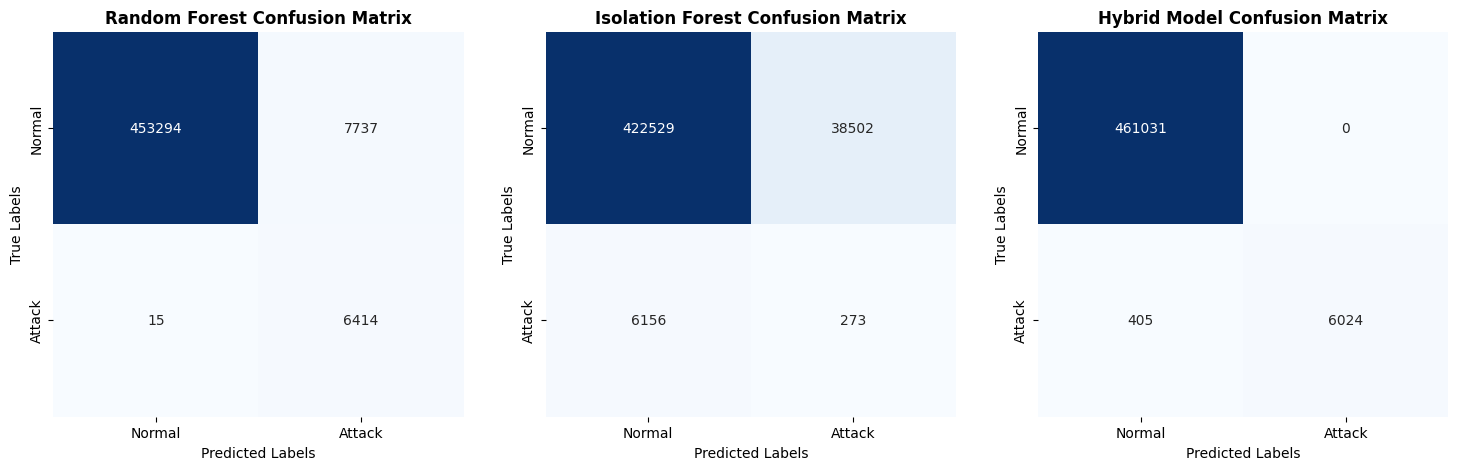

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# 1.Confusion Matrix of all Models
cm_rf=confusion_matrix(y_test,y_test_pred)
cm_iso=confusion_matrix(y_test,y_test_anomaly)
cm_hybrid=confusion_matrix(y_test,test_hybrid_binary_pred)

cms=[cm_rf,cm_iso,cm_hybrid]
titels=["Random Forest Confusion Matrix","Isolation Forest Confusion Matrix","Hybrid Model Confusion Matrix"]


# 2.Plot

fig,axes=plt.subplots(1,3,figsize=(18,5))

for i,ax in enumerate(axes):
    sns.heatmap(cms[i],annot=True,fmt="d",cmap="Blues",cbar=False,
                xticklabels=["Normal","Attack"],yticklabels=["Normal","Attack"],ax=ax)
    ax.set_title(titels[i],fontsize=12,fontweight='bold')
    ax.set_xlabel("Predicted Labels", fontsize=10)
    ax.set_ylabel("True Labels", fontsize=10)

plt.tight_layout
plt.show()


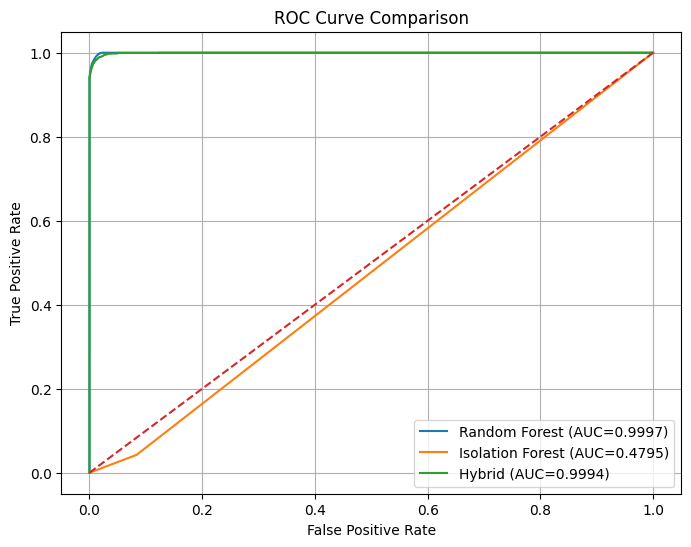

In [5]:
from sklearn.metrics import roc_curve,auc,precision_recall_curve,average_precision_score

#ROC CURVE

rf_fpr,rf_tpr,_=roc_curve(y_test,y_test_prob)
iso_fpr,iso_tpr,_=roc_curve(y_test,y_test_anomaly)
hyb_fpr,hyb_tpr,_=roc_curve(y_test,test_hybrid_risk)

rf_auc=auc(rf_fpr,rf_tpr)
iso_auc = auc(iso_fpr, iso_tpr)
hyb_auc=auc(hyb_fpr,hyb_tpr)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr,rf_tpr,label=f"Random Forest (AUC={rf_auc:.4f})")
plt.plot(iso_fpr, iso_tpr, label=f"Isolation Forest (AUC={iso_auc:.4f})")
plt.plot(hyb_fpr,hyb_tpr,label=f"Hybrid (AUC={hyb_auc:.4f})")

plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()

plt.show()


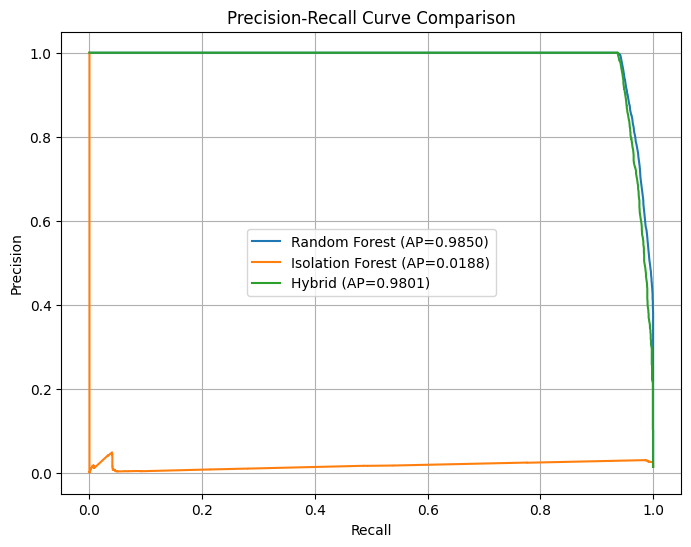

In [6]:
# ==========================================
# PRECISION-RECALL CURVES
# ==========================================

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

iso_precision, iso_recall, _ = precision_recall_curve(
    y_test,
    test_anomaly_score
)

hyb_precision, hyb_recall, _ = precision_recall_curve(
    y_test,
    test_hybrid_risk
)

rf_pr_auc = average_precision_score(y_test, y_test_prob)
iso_pr_auc = average_precision_score(y_test, test_anomaly_score)
hyb_pr_auc = average_precision_score(y_test, test_hybrid_risk)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (AP={rf_pr_auc:.4f})"
)

plt.plot(
    iso_recall,
    iso_precision,
    label=f"Isolation Forest (AP={iso_pr_auc:.4f})"
)

plt.plot(
    hyb_recall,
    hyb_precision,
    label=f"Hybrid (AP={hyb_pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.show()